In [2]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [3]:
import yfinance as yf


In [4]:
from datetime import datetime
end = datetime.now()
start = datetime(end.year-20, end.month, end.day)

In [5]:
stock = "GOOG"
google_data = yf.download(stock, start, end)

[*********************100%***********************]  1 of 1 completed


In [6]:
google_data.head()

Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2005-01-24,4.485014,4.698692,4.475087,4.682809,563010421
2005-01-25,4.395671,4.522737,4.375072,4.515292,427966132
2005-01-26,4.696458,4.700677,4.446050,4.449028,494161321
2005-01-27,4.667671,4.687028,4.596195,4.684546,266089645
2005-01-28,4.723758,4.831962,4.624488,4.715815,490158373


In [7]:
google_data.shape

(5031, 5)

In [8]:
google_data.describe()

Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
count,5031.000000,5031.000000,5031.000000,5031.000000,5.031000e+03
mean,49.027712,49.524420,48.517134,49.006606,1.080099e+08
std,46.954137,47.446360,46.461633,46.924088,1.414124e+08
min,4.342810,4.427437,4.282752,4.350503,1.584340e+05
25%,13.354034,13.499091,13.219150,13.363837,2.647220e+07
50%,28.179106,28.473584,27.953042,28.242035,4.993045e+07
75%,65.335987,65.639150,64.695794,65.081906,1.315954e+08
max,199.630005,203.839996,199.440002,200.509995,1.650833e+09


In [9]:
google_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5031 entries, 2005-01-24 to 2025-01-21
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, GOOG)   5031 non-null   float64
 1   (High, GOOG)    5031 non-null   float64
 2   (Low, GOOG)     5031 non-null   float64
 3   (Open, GOOG)    5031 non-null   float64
 4   (Volume, GOOG)  5031 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 235.8 KB


In [10]:
google_data.isna().sum()

Price   Ticker
Close   GOOG      0
High    GOOG      0
Low     GOOG      0
Open    GOOG      0
Volume  GOOG      0
dtype: int64

In [11]:
import matplotlib.pyplot as plt
%matplotlib inline

In [12]:
print(google_data.columns)
print(google_data.empty)


MultiIndex([( 'Close', 'GOOG'),
            (  'High', 'GOOG'),
            (   'Low', 'GOOG'),
            (  'Open', 'GOOG'),
            ('Volume', 'GOOG')],
           names=['Price', 'Ticker'])
False


Text(0.5, 1.0, 'Closing Price of Google Stock Data')

<Figure size 1500x500 with 0 Axes>

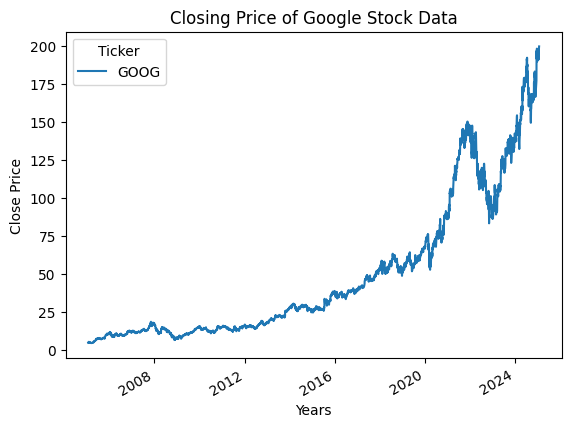

In [13]:
plt.figure(figsize=(15, 5))
google_data['Close'].plot()
plt.xlabel("Years")
plt.ylabel("Close Price")
plt.title("Closing Price of Google Stock Data")


In [14]:
def plot_graph(figsize, values, column_name):
    plt.figure()
    values.plot(figsize = figsize)
    plt.xlabel("years")
    plt.ylabel(column_name)
    plt.title(f"{column_name} of Google data")
    

In [15]:
google_data.columns

MultiIndex([( 'Close', 'GOOG'),
            (  'High', 'GOOG'),
            (   'Low', 'GOOG'),
            (  'Open', 'GOOG'),
            ('Volume', 'GOOG')],
           names=['Price', 'Ticker'])

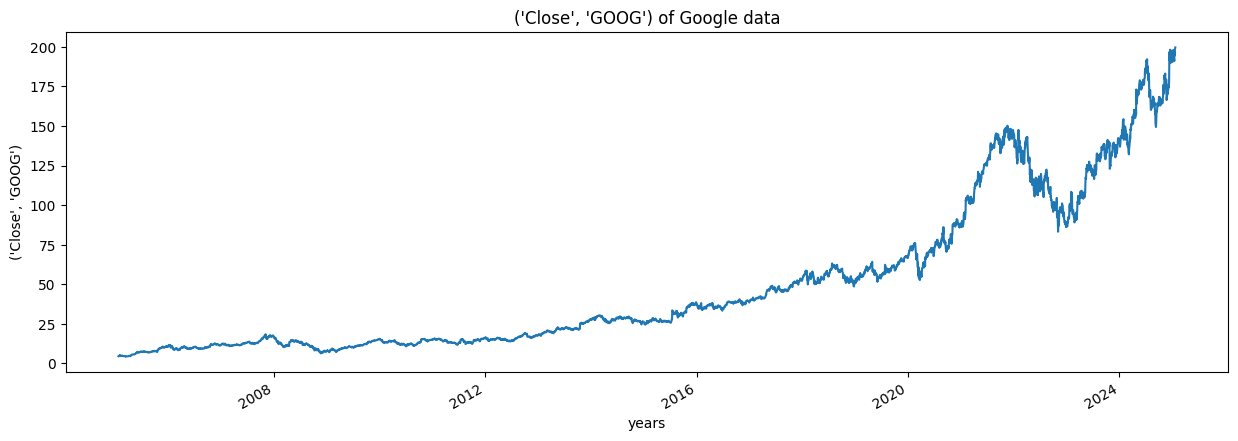

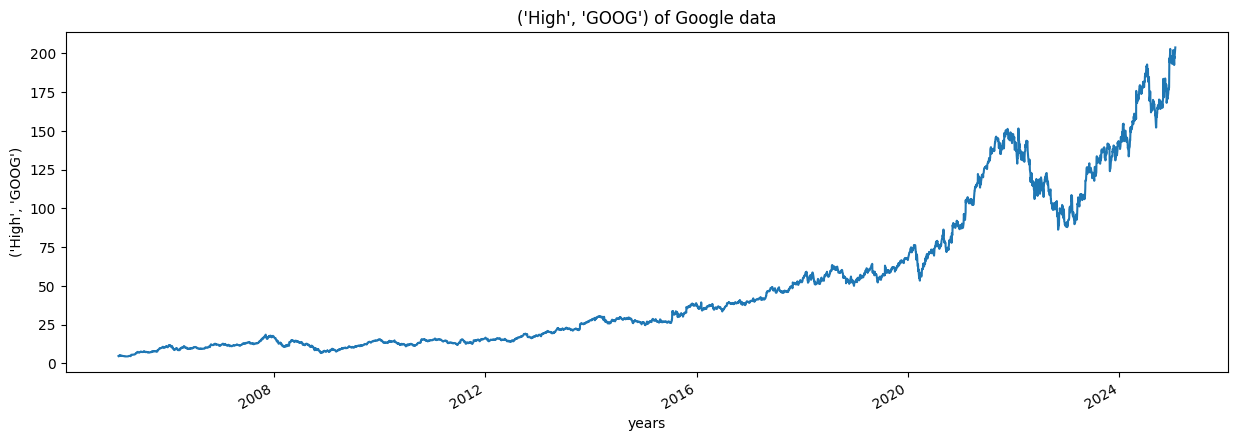

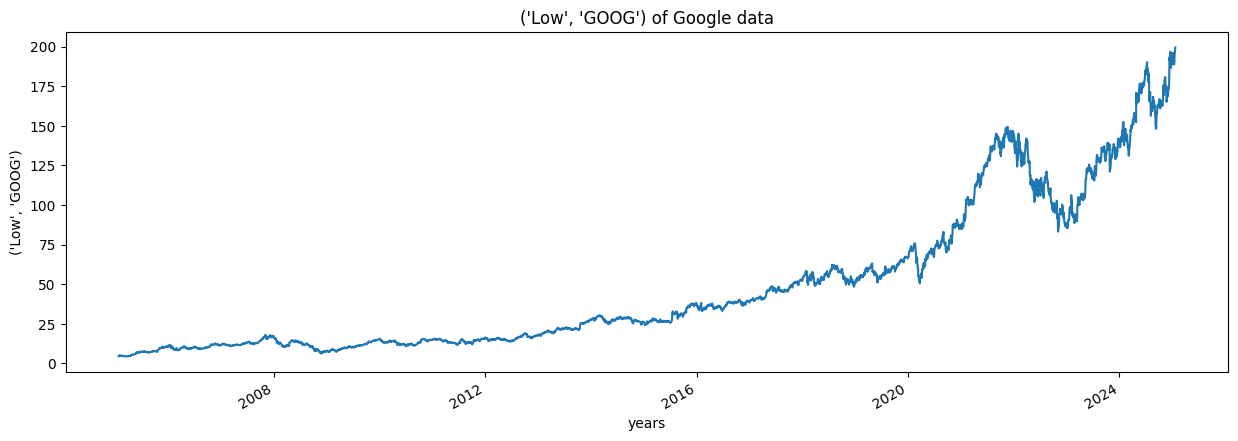

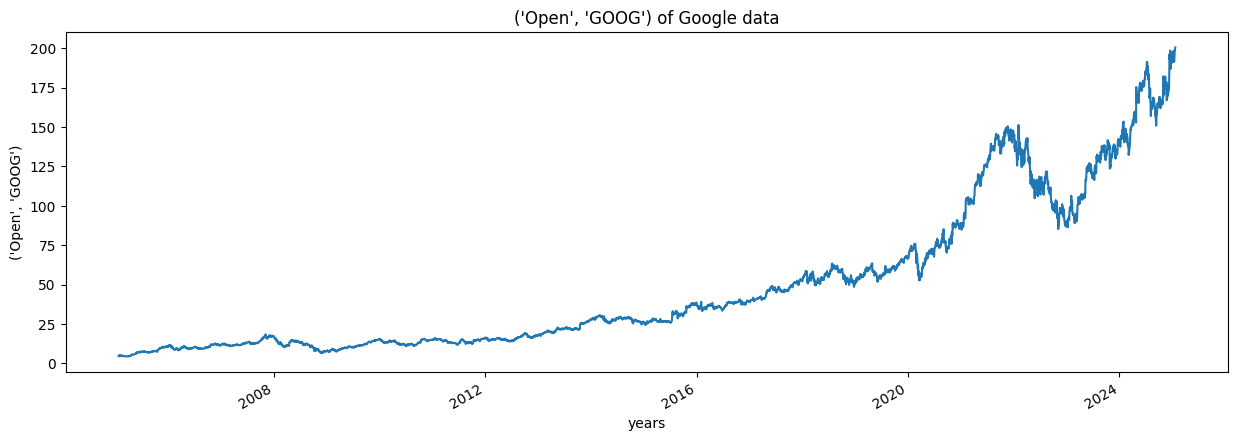

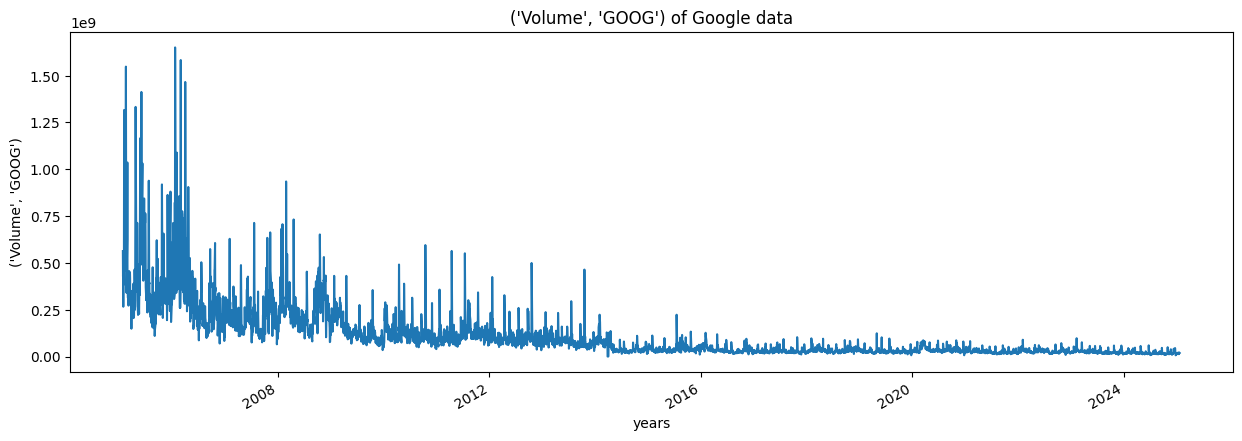

In [16]:
for column in google_data.columns:
    plot_graph((15,5),google_data[column], column)

In [17]:
temp_data = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
print(sum(temp_data[1:6])/5)

40.0


In [18]:
import pandas as pd
data = pd.DataFrame([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
data.head()

,0
0,10
1,20
2,30
3,40
4,50


In [19]:
data['MA'] = data.rolling(5).mean()
data

,0,MA
0,10,NaN
1,20,NaN
2,30,NaN
3,40,NaN
4,50,30.0
5,60,40.0
6,70,50.0
7,80,60.0
8,90,70.0
9,100,80.0


In [20]:
for i in range(2004,2025):
    print(i,list(google_data.index.year).count(i))

2004 0
2005 238
2006 251
2007 251
2008 253
2009 252
2010 252
2011 252
2012 250
2013 252
2014 252
2015 252
2016 252
2017 251
2018 251
2019 252
2020 253
2021 252
2022 251
2023 250
2024 252


In [21]:
google_data['MA_for_250_days'] = google_data['Close'].rolling(250).mean()

In [22]:
google_data['MA_for_250_days'][0:250].tail()

Date
2006-01-12         NaN
2006-01-13         NaN
2006-01-17         NaN
2006-01-18         NaN
2006-01-19    7.221239
Name: MA_for_250_days, dtype: float64

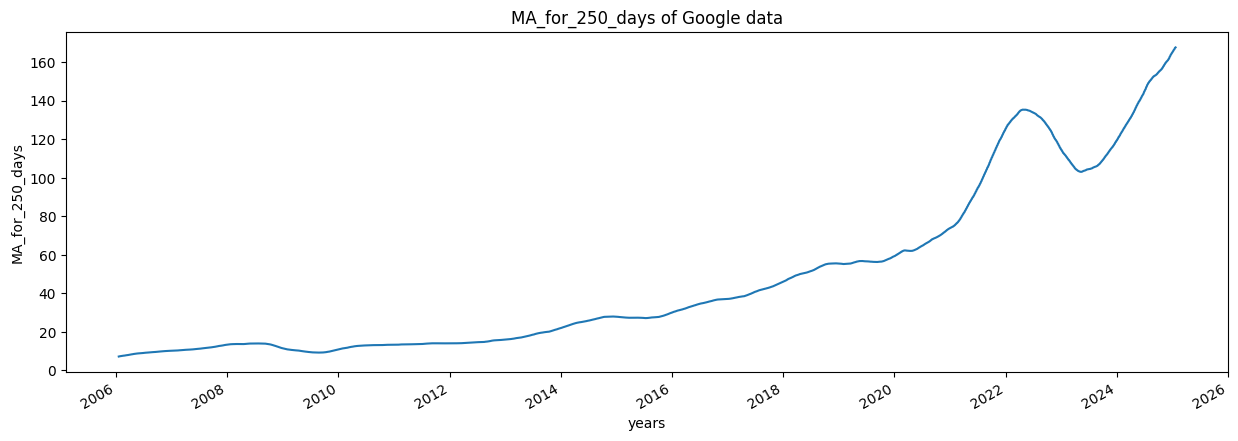

In [23]:
plot_graph((15,5), google_data['MA_for_250_days'], 'MA_for_250_days')

<Figure size 640x480 with 0 Axes>

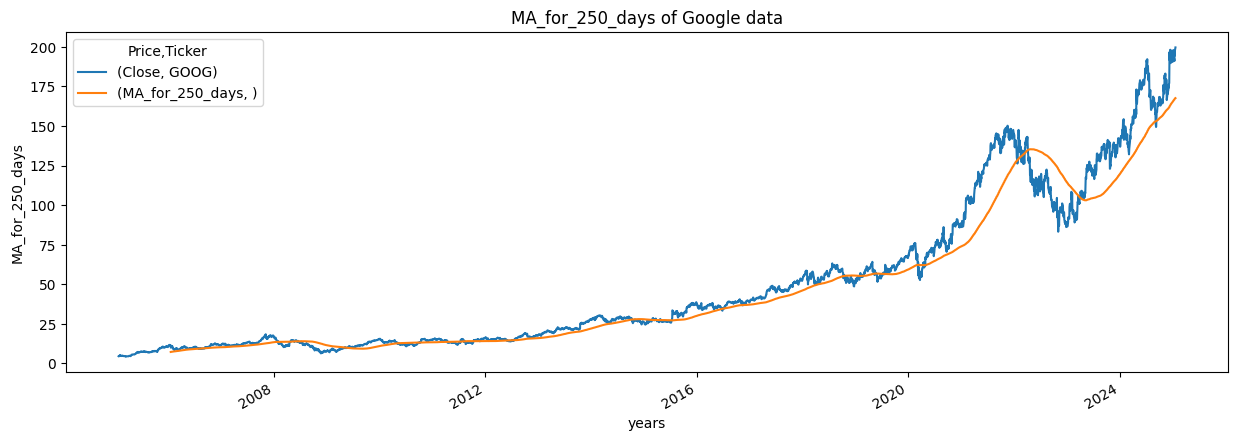

In [24]:
plot_graph((15,5), google_data[['Close','MA_for_250_days']], 'MA_for_250_days')

<Figure size 640x480 with 0 Axes>

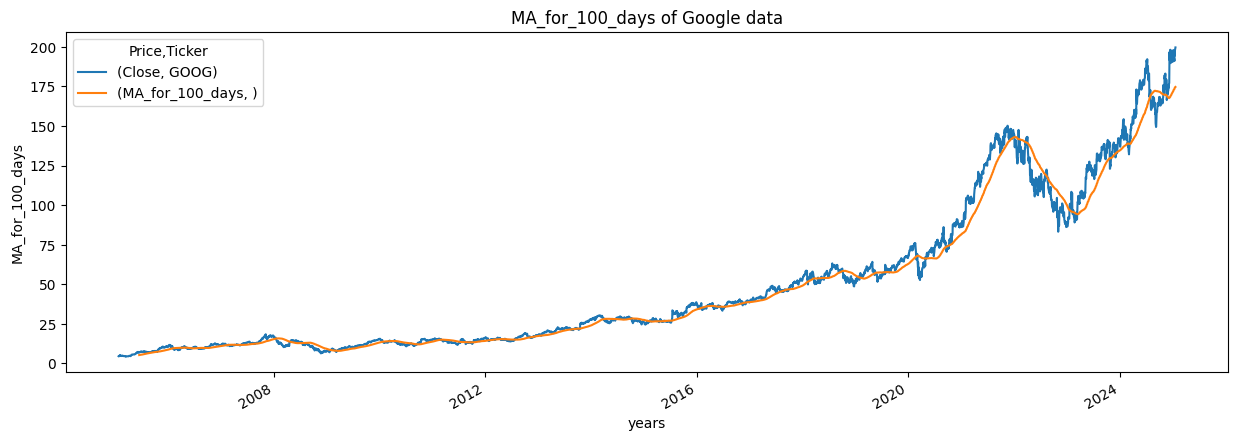

In [25]:
google_data['MA_for_100_days'] = google_data['Close'].rolling(100).mean()
plot_graph((15,5), google_data[['Close','MA_for_100_days']], 'MA_for_100_days')

<Figure size 640x480 with 0 Axes>

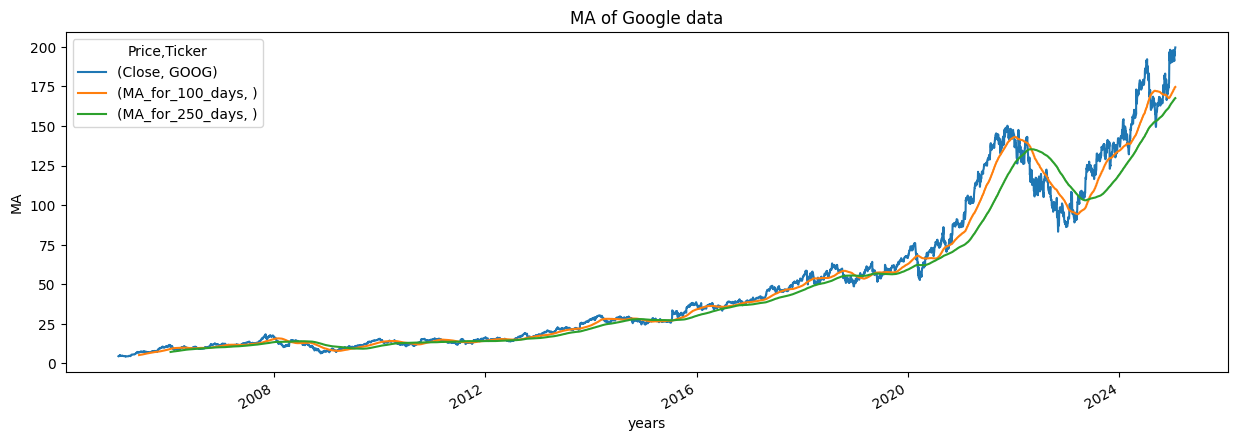

In [26]:
plot_graph((15,5), google_data[['Close','MA_for_100_days', 'MA_for_250_days']], 'MA')

In [27]:
google_data['percentage_change_cp'] = google_data['Close'].pct_change()
google_data[['Close','percentage_change_cp']].head()

Price,Close,percentage_change_cp
Ticker,GOOG,
Date,,
2005-01-24,4.485014,NaN
2005-01-25,4.395671,-0.019920
2005-01-26,4.696458,0.068428
2005-01-27,4.667671,-0.006130
2005-01-28,4.723758,0.012016


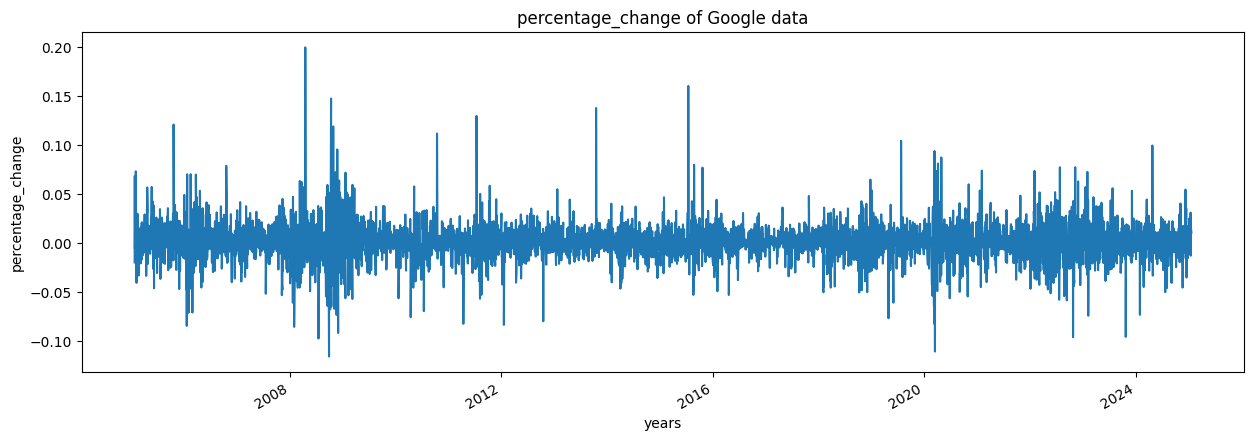

In [28]:
plot_graph((15,5), google_data['percentage_change_cp'], 'percentage_change')

In [29]:
Adj_close_price = google_data[['Close']]

In [30]:
max(Adj_close_price.values),min(Adj_close_price.values) 

(array([199.63000488]), array([4.34281015]))

In [31]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(Adj_close_price)
scaled_data

array([[7.28177841e-04],
       [2.70684485e-04],
       [1.81091090e-03],
       ...,
       [9.73270131e-01],
       [9.89349011e-01],
       [1.00000000e+00]])

In [32]:
len(scaled_data)

5031

In [33]:
x_data = []
y_data = []

for i in range(100, len(scaled_data)):
    x_data.append(scaled_data[i-100:i])
    y_data.append(scaled_data[i])
    
import numpy as np
x_data, y_data = np.array(x_data), np.array(y_data)

In [34]:
x_data[0],y_data[0]

(array([[7.28177841e-04],
        [2.70684485e-04],
        [1.81091090e-03],
        [1.66350166e-03],
        [1.95070440e-03],
        [2.62169710e-03],
        [2.14895274e-03],
        [3.93572233e-03],
        [4.55842508e-03],
        [3.73239276e-03],
        [2.67379857e-03],
        [3.00548461e-03],
        [2.10828829e-03],
        [1.65079249e-03],
        [1.57708177e-03],
        [2.28747166e-03],
        [2.57213501e-03],
        [2.97625719e-03],
        [2.91144655e-03],
        [2.91779747e-03],
        [2.08159538e-03],
        [2.40947233e-03],
        [1.76643492e-03],
        [1.38264740e-03],
        [1.65205975e-03],
        [1.40679360e-03],
        [1.29496026e-03],
        [1.52751969e-03],
        [1.38645893e-03],
        [1.75626759e-03],
        [1.29750209e-03],
        [8.08237042e-04],
        [6.34134895e-04],
        [3.57097048e-04],
        [0.00000000e+00],
        [4.60035189e-04],
        [7.75198093e-05],
        [5.46447753e-04],
        [6.4

In [35]:

int(len(x_data)*0.7)

3451

In [36]:
4908-100-int(len(x_data)*0.7)

1357

In [37]:
splitting_len = int(len(x_data)*0.7)
x_train = x_data[:splitting_len]
y_train = y_data[:splitting_len]

x_test = x_data[splitting_len:]
y_test = y_data[splitting_len:]

In [38]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(3451, 100, 1)
(3451, 1)
(1480, 100, 1)
(1480, 1)


In [39]:
from keras.models import Sequential # type: ignore
from keras.layers import Dense, LSTM # type: ignore

2025-01-22 19:57:45.815429: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [40]:
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape=(x_train.shape[1],1)))
model.add(LSTM(64,return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

/Users/ansh/Music/AP/AP_Code/Major-Project/PY/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [41]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [42]:
model.fit(x_train, y_train, batch_size=1, epochs = 2)

Epoch 1/2
3451/3451 ━━━━━━━━━━━━━━━━━━━━ 142s 40ms/step - loss: 1.5574e-04
Epoch 2/2
3451/3451 ━━━━━━━━━━━━━━━━━━━━ 150s 44ms/step - loss: 5.6443e-05


In [43]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [44]:
predictions = model.predict(x_test)

47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step


In [45]:
predictions

array([[0.26868218],
       [0.27139738],
       [0.27169263],
       ...,
       [0.9038086 ],
       [0.9033346 ],
       [0.91078347]], dtype=float32)

In [46]:
inv_predictions = scaler.inverse_transform(predictions)
inv_predictions

array([[ 56.813   ],
       [ 57.343246],
       [ 57.4009  ],
       ...,
       [180.84506 ],
       [180.75249 ],
       [182.20715 ]], dtype=float32)

In [47]:
inv_y_test = scaler.inverse_transform(y_test)
inv_y_test

array([[ 57.89348602],
       [ 57.68572998],
       [ 56.96033859],
       ...,
       [194.41000366],
       [197.55000305],
       [199.63000488]])

In [48]:
rmse = np.sqrt(np.mean( (inv_predictions - inv_y_test)**2))

In [49]:
rmse

5.932718300283362

In [50]:
ploting_data = pd.DataFrame(
 {
  'original_test_data': inv_y_test.reshape(-1),
    'predictions': inv_predictions.reshape(-1)
 } ,
    index = google_data.index[splitting_len+100:]
)
ploting_data.head()

,original_test_data,predictions
Date,,
2019-03-05,57.893486,56.813000
2019-03-06,57.685730,57.343246
2019-03-07,56.960339,57.400902
2019-03-08,56.911514,56.933079
2019-03-11,58.577522,56.674339


<Figure size 640x480 with 0 Axes>

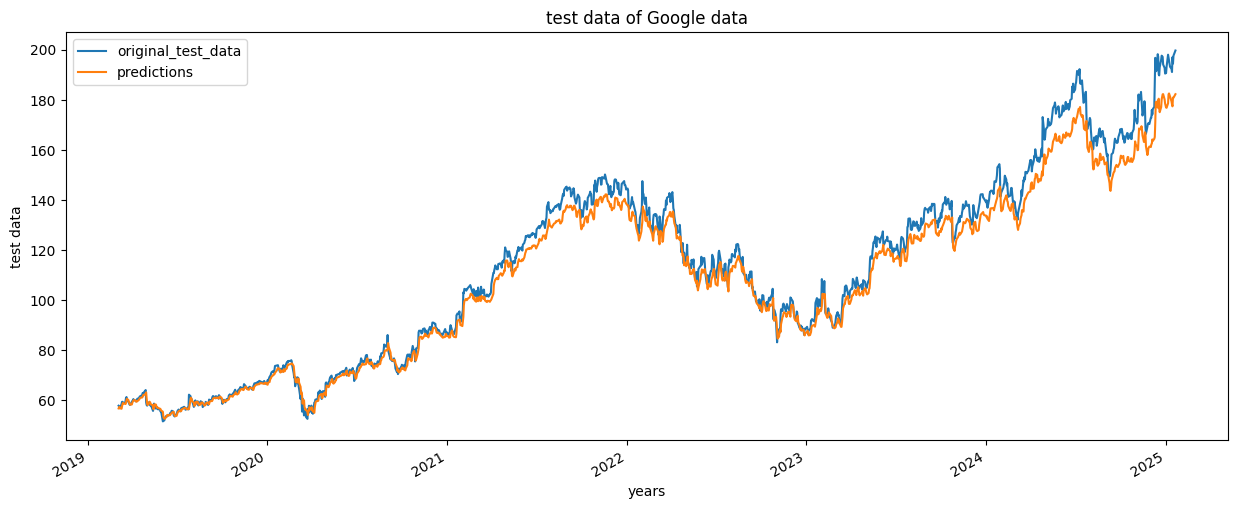

In [51]:
plot_graph((15,6), ploting_data, 'test data')

<Figure size 640x480 with 0 Axes>

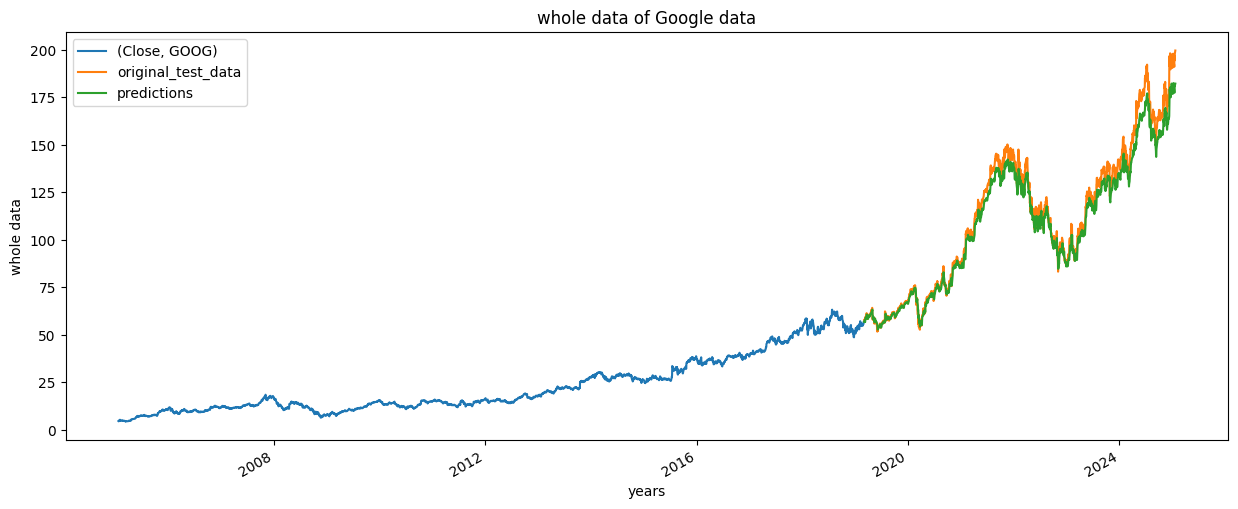

In [52]:
plot_graph((15,6), pd.concat([Adj_close_price[:splitting_len+100],ploting_data], axis=0), 'whole data')

In [53]:
model.save("Latest_stock_price_model.keras")